# Model Building, Training, and Evaluation

This notebook builds, trains, and evaluates classification models for fraud detection on **both** datasets prepared in `feature-engineering.ipynb`:
- **Fraud_Data.csv** (e-commerce transactions)
- **creditcard.csv** (bank credit card transactions)

The two datasets are treated as **independent modeling problems**, each with its own pipeline. For each dataset we:
1. Load the preprocessed train (SMOTE-resampled) and test (untouched, natural distribution) splits.
2. Train a **Logistic Regression** baseline (interpretable).
3. Train an **XGBoost** ensemble model with hyperparameter tuning (`RandomizedSearchCV`).
4. Run **Stratified 5-Fold cross-validation** for robustness.
5. Compare models using **AUC-PR**, **F1-Score**, and **Confusion Matrices**, and select the best model.
6. Persist the selected models to `../models/` for use in `shap-explainability.ipynb`.

**Primary metrics:** AUC-PR (Average Precision) and F1-Score are used as the primary evaluation metrics because both datasets are highly imbalanced — overall accuracy would be misleading (e.g., a model that always predicts 'legitimate' would score >99% accuracy on the credit card data while catching zero fraud).

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append(os.path.abspath('../'))
from src.modeling import (
    train_logistic_regression,
    tune_xgboost,
    evaluate_classifier,
    cross_validate_classifier,
    plot_confusion_matrix,
    plot_pr_curves,
)

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)
pd.set_option('display.max_columns', None)

## 1. Load Preprocessed Data
We load the SMOTE-resampled training sets and the untouched (natural-distribution) test sets produced by `feature-engineering.ipynb`. Resampling was applied to the **training data only**, so test-set evaluation reflects real-world class proportions.

In [2]:
# Fraud (e-commerce) dataset
X_fraud_train = pd.read_csv('../data/processed/fraud_X_train_resampled.csv')
y_fraud_train = pd.read_csv('../data/processed/fraud_y_train_resampled.csv').squeeze()
X_fraud_test = pd.read_csv('../data/processed/fraud_X_test.csv')
y_fraud_test = pd.read_csv('../data/processed/fraud_y_test.csv').squeeze()

# Credit Card dataset
X_credit_train = pd.read_csv('../data/processed/credit_X_train_resampled.csv')
y_credit_train = pd.read_csv('../data/processed/credit_y_train_resampled.csv').squeeze()
X_credit_test = pd.read_csv('../data/processed/credit_X_test.csv')
y_credit_test = pd.read_csv('../data/processed/credit_y_test.csv').squeeze()

print('Fraud  -> train:', X_fraud_train.shape, ' test:', X_fraud_test.shape)
print('Credit -> train:', X_credit_train.shape, ' test:', X_credit_test.shape)

print('\nFraud train class balance (post-SMOTE):')
print(y_fraud_train.value_counts(normalize=True))
print('\nFraud test class balance (natural):')
print(y_fraud_test.value_counts(normalize=True))

print('\nCredit train class balance (post-SMOTE):')
print(y_credit_train.value_counts(normalize=True))
print('\nCredit test class balance (natural):')
print(y_credit_test.value_counts(normalize=True))

Fraud  -> train: (219136, 33)  test: (30223, 33)
Credit -> train: (453204, 30)  test: (56746, 30)

Fraud train class balance (post-SMOTE):
class
0    0.5
1    0.5
Name: proportion, dtype: float64

Fraud test class balance (natural):
class
0    0.906363
1    0.093637
Name: proportion, dtype: float64

Credit train class balance (post-SMOTE):
Class
0    0.5
1    0.5
Name: proportion, dtype: float64

Credit test class balance (natural):
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


---
# Part A: E-Commerce Fraud Data (`Fraud_Data.csv`)

## A1. Baseline Model — Logistic Regression
Logistic Regression provides an interpretable baseline. Coefficients can be directly inspected to understand the direction and magnitude of each feature's effect on the fraud log-odds.

AUC-PR:   0.6780
F1-Score: 0.5787

Classification Report:
              precision    recall  f1-score   support

           0     0.9668    0.9279    0.9469     27393
           1     0.4976    0.6915    0.5787      2830

    accuracy                         0.9057     30223
   macro avg     0.7322    0.8097    0.7628     30223
weighted avg     0.9229    0.9057    0.9125     30223



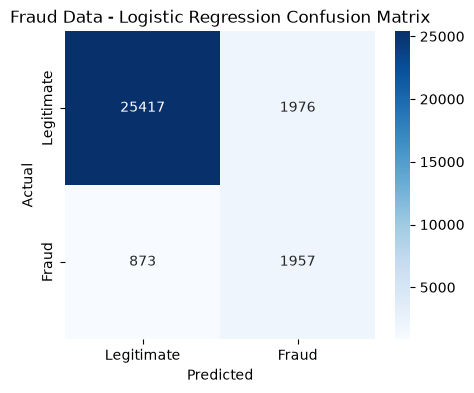

In [3]:
fraud_lr = train_logistic_regression(X_fraud_train, y_fraud_train)
fraud_lr_results = evaluate_classifier(fraud_lr, X_fraud_test, y_fraud_test, model_name='Logistic Regression (Fraud)')

print(f"AUC-PR:   {fraud_lr_results['auc_pr']:.4f}")
print(f"F1-Score: {fraud_lr_results['f1_score']:.4f}")
print('\nClassification Report:')
print(fraud_lr_results['classification_report'])

plot_confusion_matrix(
    fraud_lr_results['confusion_matrix'],
    title='Fraud Data - Logistic Regression Confusion Matrix',
    save_path='../reports/figures/fraud_lr_confusion_matrix.png'
)
plt.show()

## A2. Ensemble Model — XGBoost (Hyperparameter Tuned)
We tune `n_estimators`, `max_depth`, `learning_rate`, and `subsample` using `RandomizedSearchCV` with Stratified 3-Fold CV, optimizing for AUC-PR (average precision).

Best hyperparameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2}

AUC-PR:   0.7066
F1-Score: 0.6840

Classification Report:
              precision    recall  f1-score   support

           0     0.9545    0.9958    0.9747     27393
           1     0.9307    0.5406    0.6840      2830

    accuracy                         0.9532     30223
   macro avg     0.9426    0.7682    0.8293     30223
weighted avg     0.9523    0.9532    0.9475     30223



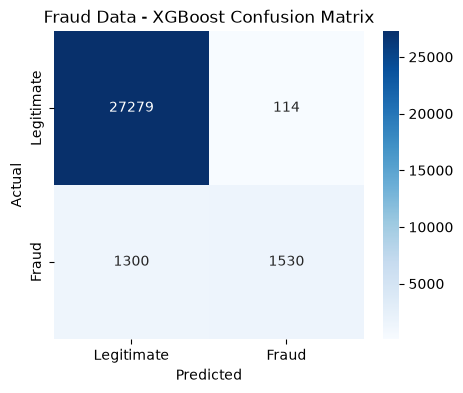

In [4]:
fraud_param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

fraud_xgb, fraud_xgb_best_params, fraud_xgb_cv_results = tune_xgboost(
    X_fraud_train, y_fraud_train, param_distributions=fraud_param_dist, n_iter=6, cv=3
)

print('Best hyperparameters:', fraud_xgb_best_params)

fraud_xgb_results = evaluate_classifier(fraud_xgb, X_fraud_test, y_fraud_test, model_name='XGBoost (Fraud)')

print(f"\nAUC-PR:   {fraud_xgb_results['auc_pr']:.4f}")
print(f"F1-Score: {fraud_xgb_results['f1_score']:.4f}")
print('\nClassification Report:')
print(fraud_xgb_results['classification_report'])

plot_confusion_matrix(
    fraud_xgb_results['confusion_matrix'],
    title='Fraud Data - XGBoost Confusion Matrix',
    save_path='../reports/figures/fraud_xgb_confusion_matrix.png'
)
plt.show()

## A3. Precision-Recall Curve Comparison

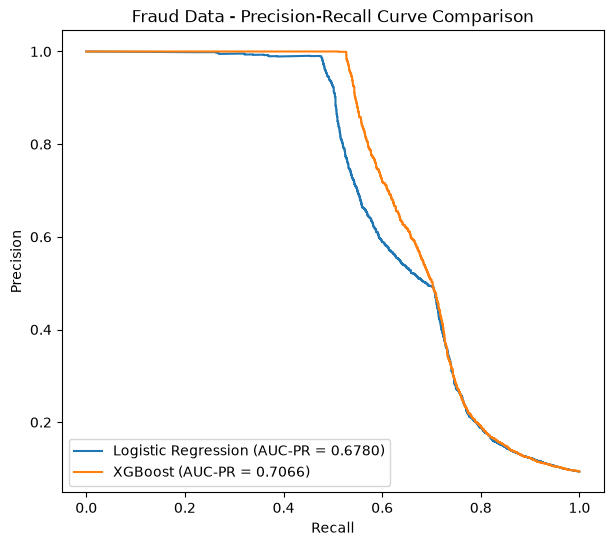

In [5]:
plot_pr_curves(
    y_fraud_test,
    {'Logistic Regression': fraud_lr_results['y_proba'], 'XGBoost': fraud_xgb_results['y_proba']},
    title='Fraud Data - Precision-Recall Curve Comparison',
    save_path='../reports/figures/fraud_pr_curve_comparison.png'
)
plt.show()

## A4. Cross-Validation (Stratified K-Fold, k=5)
We run 5-fold cross-validation **on the SMOTE-resampled training set** for both models, reporting the mean and standard deviation of AUC-PR and F1-Score across folds. This gives a sense of the variance of each model's performance independent of the single train/test split. Note that, because the folds are drawn from an already-resampled training set, these CV scores reflect performance on a balanced distribution — the **test-set metrics above remain the primary indicator of real-world performance**, since the test set retains the natural class imbalance.

In [6]:
print('Running 5-fold CV for Logistic Regression (Fraud)...')
fraud_lr_cv = cross_validate_classifier(fraud_lr, X_fraud_train, y_fraud_train, cv=5)
print(fraud_lr_cv)

print('\nRunning 5-fold CV for XGBoost (Fraud)...')
fraud_xgb_cv = cross_validate_classifier(fraud_xgb, X_fraud_train, y_fraud_train, cv=5)
print(fraud_xgb_cv)

Running 5-fold CV for Logistic Regression (Fraud)...


{'auc_pr_mean': np.float64(0.93226779857981), 'auc_pr_std': np.float64(0.0008167338594889766), 'f1_mean': np.float64(0.8315909745419425), 'f1_std': np.float64(0.0009103951700502221)}

Running 5-fold CV for XGBoost (Fraud)...


{'auc_pr_mean': np.float64(0.9893132072545979), 'auc_pr_std': np.float64(0.00012033038911420933), 'f1_mean': np.float64(0.9592461452311773), 'f1_std': np.float64(0.0018320244717740578)}


## A5. Model Comparison & Selection (Fraud Data)

In [7]:
fraud_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Test AUC-PR': fraud_lr_results['auc_pr'],
        'Test F1-Score': fraud_lr_results['f1_score'],
        'CV AUC-PR (mean)': fraud_lr_cv['auc_pr_mean'],
        'CV AUC-PR (std)': fraud_lr_cv['auc_pr_std'],
        'CV F1 (mean)': fraud_lr_cv['f1_mean'],
        'CV F1 (std)': fraud_lr_cv['f1_std'],
    },
    {
        'Model': 'XGBoost (Tuned)',
        'Test AUC-PR': fraud_xgb_results['auc_pr'],
        'Test F1-Score': fraud_xgb_results['f1_score'],
        'CV AUC-PR (mean)': fraud_xgb_cv['auc_pr_mean'],
        'CV AUC-PR (std)': fraud_xgb_cv['auc_pr_std'],
        'CV F1 (mean)': fraud_xgb_cv['f1_mean'],
        'CV F1 (std)': fraud_xgb_cv['f1_std'],
    },
])
fraud_comparison

,Model,Test AUC-PR,Test F1-Score,CV AUC-PR (mean),CV AUC-PR (std),CV F1 (mean),CV F1 (std)
0,Logistic Regression,0.678019,0.578737,0.932268,0.000817,0.831591,0.000910
1,XGBoost (Tuned),0.706552,0.683952,0.989313,0.000120,0.959246,0.001832


### Model Selection — Fraud Data (E-Commerce)

| Model | Test AUC-PR | Test F1 | Fraud Precision | Fraud Recall | CV AUC-PR (mean ± std) | CV F1 (mean ± std) |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.6780 | 0.5787 | 0.4976 | 0.6915 | 0.9323 ± 0.0008 | 0.8316 ± 0.0009 |
| **XGBoost (Tuned)** | **0.7066** | **0.6840** | **0.9307** | 0.5406 | 0.9893 ± 0.0001 | 0.9592 ± 0.0018 |

Best XGBoost hyperparameters: `n_estimators=100, max_depth=7, learning_rate=0.2, subsample=0.8`.

**Selected model: XGBoost (Tuned)**

- XGBoost improves both primary metrics over the Logistic Regression baseline: **AUC-PR rises from 0.678 to 0.707**, and **F1 from 0.579 to 0.684**.
- The biggest practical gain is precision: only **49.8%** of Logistic Regression's fraud alerts are real fraud, versus **93.1%** for XGBoost. At Adey's transaction volumes, this roughly halves the false-alarm rate — a direct customer-trust benefit, since fewer legitimate customers experience declined or flagged transactions.
- The trade-off is recall: XGBoost flags 54.1% of fraud vs. 69.2% for Logistic Regression. Because XGBoost outputs a probability, the decision threshold can be lowered in production to trade some of that precision advantage back for recall, while remaining far ahead of Logistic Regression at any comparable threshold (see the Precision-Recall curve above — XGBoost's curve sits at or above LR's across almost the entire recall range).
- 5-fold CV on the resampled training set confirms XGBoost is both stronger (AUC-PR 0.989 vs 0.932, F1 0.959 vs 0.832) and more stable (lower standard deviation) than Logistic Regression.
- **Interpretability:** Logistic Regression remains valuable as an auditable baseline with directly-readable coefficients. However, XGBoost is selected as the production model for the e-commerce stream — its performance advantage is large, and `shap-explainability.ipynb` shows that SHAP provides the same level of per-prediction transparency for the tree ensemble as coefficients do for the linear model.

---
# Part B: Bank Credit Card Data (`creditcard.csv`)

## B1. Baseline Model — Logistic Regression

AUC-PR:   0.6750
F1-Score: 0.1000

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9738    0.9866     56651
           1     0.0530    0.8737    0.1000        95

    accuracy                         0.9737     56746
   macro avg     0.5264    0.9238    0.5433     56746
weighted avg     0.9982    0.9737    0.9852     56746



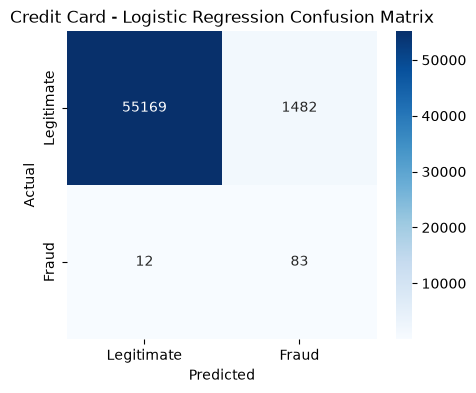

In [8]:
credit_lr = train_logistic_regression(X_credit_train, y_credit_train)
credit_lr_results = evaluate_classifier(credit_lr, X_credit_test, y_credit_test, model_name='Logistic Regression (Credit Card)')

print(f"AUC-PR:   {credit_lr_results['auc_pr']:.4f}")
print(f"F1-Score: {credit_lr_results['f1_score']:.4f}")
print('\nClassification Report:')
print(credit_lr_results['classification_report'])

plot_confusion_matrix(
    credit_lr_results['confusion_matrix'],
    title='Credit Card - Logistic Regression Confusion Matrix',
    save_path='../reports/figures/credit_lr_confusion_matrix.png'
)
plt.show()

## B2. Ensemble Model — XGBoost (Hyperparameter Tuned)

Best hyperparameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2}

AUC-PR:   0.8162
F1-Score: 0.7817

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9996    0.9996     56651
           1     0.7549    0.8105    0.7817        95

    accuracy                         0.9992     56746
   macro avg     0.8773    0.9050    0.8907     56746
weighted avg     0.9993    0.9992    0.9993     56746



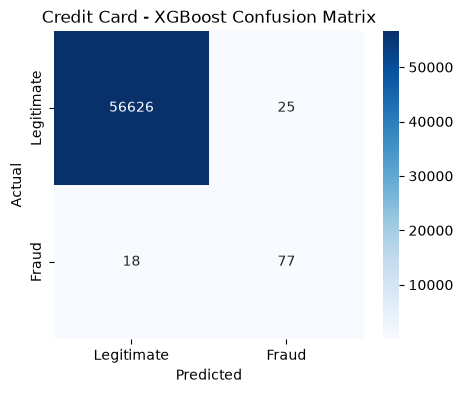

In [9]:
credit_param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

credit_xgb, credit_xgb_best_params, credit_xgb_cv_results = tune_xgboost(
    X_credit_train, y_credit_train, param_distributions=credit_param_dist, n_iter=6, cv=3
)

print('Best hyperparameters:', credit_xgb_best_params)

credit_xgb_results = evaluate_classifier(credit_xgb, X_credit_test, y_credit_test, model_name='XGBoost (Credit Card)')

print(f"\nAUC-PR:   {credit_xgb_results['auc_pr']:.4f}")
print(f"F1-Score: {credit_xgb_results['f1_score']:.4f}")
print('\nClassification Report:')
print(credit_xgb_results['classification_report'])

plot_confusion_matrix(
    credit_xgb_results['confusion_matrix'],
    title='Credit Card - XGBoost Confusion Matrix',
    save_path='../reports/figures/credit_xgb_confusion_matrix.png'
)
plt.show()

## B3. Precision-Recall Curve Comparison

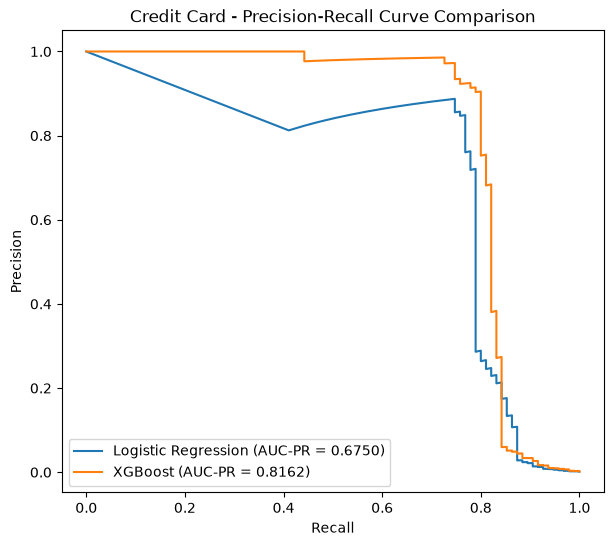

In [10]:
plot_pr_curves(
    y_credit_test,
    {'Logistic Regression': credit_lr_results['y_proba'], 'XGBoost': credit_xgb_results['y_proba']},
    title='Credit Card - Precision-Recall Curve Comparison',
    save_path='../reports/figures/credit_pr_curve_comparison.png'
)
plt.show()

## B4. Cross-Validation (Stratified K-Fold, k=5)
As with the fraud dataset, 5-fold CV is run on the SMOTE-resampled training set to assess variance across folds, while the untouched test set (with its natural ~0.17% fraud rate) remains the primary indicator of real-world performance.

In [11]:
print('Running 5-fold CV for Logistic Regression (Credit Card)...')
credit_lr_cv = cross_validate_classifier(credit_lr, X_credit_train, y_credit_train, cv=5)
print(credit_lr_cv)

print('\nRunning 5-fold CV for XGBoost (Credit Card)...')
credit_xgb_cv = cross_validate_classifier(credit_xgb, X_credit_train, y_credit_train, cv=5)
print(credit_xgb_cv)

Running 5-fold CV for Logistic Regression (Credit Card)...


{'auc_pr_mean': np.float64(0.9921447704078379), 'auc_pr_std': np.float64(0.00024180497133729324), 'f1_mean': np.float64(0.9460446147521049), 'f1_std': np.float64(0.0011476986682386794)}

Running 5-fold CV for XGBoost (Credit Card)...


{'auc_pr_mean': np.float64(0.9999804853187998), 'auc_pr_std': np.float64(1.849015499063836e-05), 'f1_mean': np.float64(0.9997573453656654), 'f1_std': np.float64(4.881962178531489e-05)}


## B5. Model Comparison & Selection (Credit Card Data)

In [12]:
credit_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Test AUC-PR': credit_lr_results['auc_pr'],
        'Test F1-Score': credit_lr_results['f1_score'],
        'CV AUC-PR (mean)': credit_lr_cv['auc_pr_mean'],
        'CV AUC-PR (std)': credit_lr_cv['auc_pr_std'],
        'CV F1 (mean)': credit_lr_cv['f1_mean'],
        'CV F1 (std)': credit_lr_cv['f1_std'],
    },
    {
        'Model': 'XGBoost (Tuned)',
        'Test AUC-PR': credit_xgb_results['auc_pr'],
        'Test F1-Score': credit_xgb_results['f1_score'],
        'CV AUC-PR (mean)': credit_xgb_cv['auc_pr_mean'],
        'CV AUC-PR (std)': credit_xgb_cv['auc_pr_std'],
        'CV F1 (mean)': credit_xgb_cv['f1_mean'],
        'CV F1 (std)': credit_xgb_cv['f1_std'],
    },
])
credit_comparison

,Model,Test AUC-PR,Test F1-Score,CV AUC-PR (mean),CV AUC-PR (std),CV F1 (mean),CV F1 (std)
0,Logistic Regression,0.675041,0.100000,0.992145,0.000242,0.946045,0.001148
1,XGBoost (Tuned),0.816159,0.781726,0.999980,0.000018,0.999757,0.000049


### Model Selection — Credit Card Data

| Model | Test AUC-PR | Test F1 | Fraud Precision | Fraud Recall | CV AUC-PR (mean ± std) | CV F1 (mean ± std) |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.6750 | 0.1000 | 0.0530 | 0.8737 | 0.9921 ± 0.0002 | 0.9460 ± 0.0011 |
| **XGBoost (Tuned)** | **0.8162** | **0.7817** | 0.7549 | **0.8105** | 0.99998 ± 0.00002 | 0.99976 ± 0.00005 |

Best XGBoost hyperparameters: `n_estimators=100, max_depth=7, learning_rate=0.2, subsample=0.8`.

**Selected model: XGBoost (Tuned)**

- This dataset makes the case for AUC-PR/F1 over CV-on-resampled-data scores very starkly: **both models score above 0.94 F1 under 5-fold CV on the balanced (SMOTE) training set**, which would suggest both are "production ready". But evaluated on the **untouched test set at the real 0.17% fraud rate**, Logistic Regression's F1 **collapses to 0.10**.
- At a recall of 87.4%, Logistic Regression's precision is only **5.3%** — for every correctly-flagged fraud transaction, roughly **18 legitimate transactions** are also flagged. A fraud-operations team would be overwhelmed by false alerts, and customers would routinely see legitimate purchases blocked.
- XGBoost achieves **AUC-PR = 0.816** and **F1 = 0.782**, with precision 75.5% and recall 81.1% — it catches almost as much fraud as Logistic Regression (81% vs 87%) while being roughly **14x more precise**.
- **Selected model: XGBoost (Tuned)** for the credit card stream. The gap between resampled-CV performance and natural-test-set performance is the key justification for evaluating on an untouched, naturally-imbalanced test set rather than relying on cross-validation scores from resampled data alone.

---
## Saving Selected Models
We persist all trained models to `../models/` so they can be reloaded directly in `shap-explainability.ipynb` without retraining.

In [13]:
joblib.dump(fraud_lr, '../models/fraud_logistic_regression.pkl')
joblib.dump(fraud_xgb, '../models/fraud_xgboost.pkl')
joblib.dump(credit_lr, '../models/credit_logistic_regression.pkl')
joblib.dump(credit_xgb, '../models/credit_xgboost.pkl')

print('Saved models to ../models/:')
for f in sorted(os.listdir('../models')):
    print(' -', f)

Saved models to ../models/:
 - credit_logistic_regression.pkl
 - credit_xgboost.pkl
 - fraud_logistic_regression.pkl
 - fraud_xgboost.pkl


## Summary

For both transaction streams, the tuned **XGBoost** ensemble is selected as the best model — it outperforms the Logistic Regression baseline on AUC-PR and F1 (the primary metrics for imbalanced data) on the held-out, naturally-imbalanced test set, most dramatically for the credit card data where Logistic Regression's precision collapses under the true 0.17% fraud rate.

| Dataset | Best Model | Test AUC-PR | Test F1 |
|---|---|---|---|
| Fraud (E-commerce) | XGBoost (Tuned) | 0.7066 | 0.6840 |
| Credit Card | XGBoost (Tuned) | 0.8162 | 0.7817 |

Both XGBoost models (`fraud_xgboost.pkl`, `credit_xgboost.pkl`) — along with the Logistic Regression baselines — are saved to `../models/`. Model interpretation continues in `shap-explainability.ipynb`.